In [1]:
#torch-1.12.1+cu113
import torch
# Set this to your TOTAL number of logical threads (usually 8, 12, or 16)
#torch.set_num_threads(torch.get_num_threads()) 
#torch.set_num_threads(14) 
print(f"Threads set to: {torch.get_num_threads()}")

N_age = 9
N_Urea = 100
N_SCRr = 5
N_eGFR = 200
N_eGFR_Class = 4


/data/home/majid/.local/lib/python3.9/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Threads set to: 128


# Data

In [3]:
import torch
import numpy as np

WINDOW_SIZE = 5
MIN_SEQ_LEN = 7
MAX_SEQ_LEN = 7
new_subj_Th = 10

DEV = 'cuda:1'

AE_FeatureExtract = 1

HORIZON = 4
ablation = 0
iteration = 8

AE_Hidden_Dim = 128

embed_Ftr_dim = 128


start_seq = MAX_SEQ_LEN - MIN_SEQ_LEN
end_seq = MAX_SEQ_LEN

PAD_VALUE = -1

data = np.load(f"../filtered_data/dataset_win-{WINDOW_SIZE}_seq-{MIN_SEQ_LEN}-{MAX_SEQ_LEN}_horiz-{HORIZON}_subj-{new_subj_Th}_v3_fold-{iteration}.npz")

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
data.close()


In [4]:
n_mech = 11
n_drug = 71+26
n_ddi = 44

X_train[:,:,12: 12 + n_mech + n_drug + n_ddi][X_train[:,:, 12: 12 + n_mech + n_drug + n_ddi]>1] = 1
X_val[:,:,12: 12 + n_mech + n_drug + n_ddi][X_val[:,:, 12: 12 + n_mech + n_drug + n_ddi]>1] = 1
X_test[:,:,12: 12 + n_mech + n_drug + n_ddi][X_test[:,:, 12: 12 + n_mech + n_drug + n_ddi]>1] = 1


# Ablation

In [5]:
def remove_egfr_features(X):

    X0 = X.copy()

    scr = X0[:,-1,5]
    age = X0[:,-1,-2]
    sex = X0[:,-1,-1]

    
    if ablation == 3:
        X[:, start_seq:end_seq, 0:8] = 0
    if ablation == 4:
        X[:, start_seq:end_seq, 8:12] = 0
    if ablation == 5:
        X[:, start_seq:end_seq, 12: 12 + n_mech + n_drug] = 0
    if ablation == 6:
        X[:, start_seq:end_seq, 12 + n_mech + n_drug: 12 + n_mech + n_drug + n_ddi] = 0
    if ablation == 9:
        X[:, start_seq:end_seq, 12: 12 + n_mech + n_drug] = 0
        X[:, start_seq:end_seq, 12 + n_mech + n_drug: 12 + n_mech + n_drug + n_ddi] = 0
    if ablation == 10:
        X[:, start_seq:end_seq, -2:-1] = 0
    if ablation == 11:
        X[:, start_seq:end_seq, -1:] = 0
    
    X[:, start_seq:end_seq, 6:8] = 0
    X[:, start_seq:end_seq, 12: 12 + n_mech] = 0
    X[:, start_seq:end_seq, 0:5] = 0
    X[:, start_seq:end_seq, 8:11] = 0

    feat = np.concatenate([
            X[:, start_seq:end_seq, 0:6]/N_SCRr,       # SCr
            X[:, start_seq:end_seq, 6:7]/N_eGFR,       # eGFR value
            X[:, start_seq:end_seq, 7:8]/N_eGFR_Class, # eGFR class
            X[:, start_seq:end_seq, 8:12]/N_Urea,      # Urea
            X[:, start_seq:end_seq, 12: 12 + n_mech + n_drug],            # Drugs Mechanisms
            X[:, start_seq:end_seq, 12 + n_mech + n_drug: 12 + n_mech + n_drug + n_ddi],            # DDI types
            X[:, start_seq:end_seq, -2:-1]//N_age/10,      # Age
            X[:, start_seq:end_seq, -1:]               # Sex
    ], axis=2)

    print(feat.shape)
    return feat, scr, age, sex


X_train, scr_train, age_train, sex_train = remove_egfr_features(X_train)
X_val, scr_val, age_val, sex_val   = remove_egfr_features(X_val)
X_test, scr_test, age_test, sex_test  = remove_egfr_features(X_test)

num_features = X_train.shape[-1]
print(f"num_features: {num_features}")
print(f"y_train: {y_train.shape}")

(47935, 7, 166)
(6650, 7, 166)
(13134, 7, 166)
num_features: 166
y_train: (47935,)


In [6]:
def compute_egfr_tensor(scr, age, sex):

    scr = torch.tensor(scr, dtype=torch.float32)
    #dev = scr.device
    #print("device: ", dev)
# as_tensor handles numpy arrays; .to(dev) handles the hardware move
    age = torch.as_tensor(age, dtype=torch.float32)#.to(dev)
    sex = torch.as_tensor(sex, dtype=torch.float32)#.to(dev)
    
    # Ensure they match the shape of scr (e.g., [Batch, 1]) to avoid broadcasting errors
    age = age.view(scr.shape)
    sex = sex.view(scr.shape)
    
    kappa = torch.where(sex==1, 0.7, 0.9)
    alpha = torch.where(sex==1, -0.241, -0.302)
    gender_mult = torch.where(sex==1, 1.012, 1.0)

    term1 = torch.minimum(scr / kappa, torch.ones_like(scr)) ** alpha
    term2 = torch.maximum(scr / kappa, torch.ones_like(scr)) ** -1.200
    term3 = 0.9938 ** age

    return 142 * term1 * term2 * term3 * gender_mult


def assign_class_tensor(egfr):
    cls = torch.zeros_like(egfr, dtype=torch.long)

    cls[egfr >= 90] = 4
    cls[(egfr >= 60) & (egfr < 90)] = 3
    cls[(egfr >= 30) & (egfr < 60)] = 2
    cls[(egfr >= 15) & (egfr < 30)] = 1
    cls[egfr < 15] = 0

    return cls
    

def compute_egfr(scr, age, is_female):
    kappa = 0.7 if is_female else 0.9
    alpha = -0.241 if is_female else -0.302
    gender_mult = 1.012 if is_female else 1.0
    
    term1 = min(scr / kappa, 1) ** alpha
    term2 = max(scr / kappa, 1) ** -1.200
    term3 = 0.9938 ** age
    
    return 142 * term1 * term2 * term3 * gender_mult


def assign_egfr_class(egfr):
    """Maps eGFR value to 1-5 categories based on your intervals"""
    if egfr >= 90: return 4     # Normal
    if egfr >= 60: return 3     # Mild
    if egfr >= 30: return 2     # Moderate
    if egfr >= 15: return 1     # Severe
    return 0                    # Failure




In [7]:
egfr_true = compute_egfr_tensor(y_train, age_train, sex_train)
true_cls_train = assign_class_tensor(egfr_true).cpu().numpy()

egfr_true = compute_egfr_tensor(y_val, age_val, sex_val)
true_cls_val = assign_class_tensor(egfr_true).cpu().numpy()

egfr_true = compute_egfr_tensor(y_test, age_test, sex_test)
true_cls_test = assign_class_tensor(egfr_true).cpu().numpy()

y_train = true_cls_train
y_val = true_cls_val
y_test = true_cls_test

In [8]:
#X_all = np.concatenate([X_train, X_val, X_test], axis=0)
#y_all = np.concatenate([y_train, y_val, y_test], axis=0)
#print(f"X_all: {X_all.shape}")

In [9]:
import matplotlib
import torch
import numpy
import pandas

print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)
print("torch:", torch.__version__)

numpy: 1.24.1
pandas: 2.2.2
matplotlib: 3.5.2
torch: 2.6.0+cu124


/data/home/majid/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/data/home/majid/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [10]:

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import xgboost as xgb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import warnings, logging, math, os, json
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s")
log = logging.getLogger(__name__)

#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# ... rest of your code
#  Feature-index constants 
IDX_SCR_MEAN  = 0
IDX_SCR_STD   = 1
IDX_SCR_MIN   = 2
IDX_SCR_MAX   = 3
IDX_SCR_SLOPE = 4
IDX_SCR_LAST  = 5
IDX_eGFR_VALUE= 6
IDX_eGFR_CLASS= 7
IDX_UREA_MEAN = 8
IDX_UREA_STD  = 9
IDX_UREA_MIN  = 10
IDX_UREA_MAX  = 11
IDX_MECH_START = 12;  IDX_MECH_END = 23   # 11 drug-mechanism one-hots
IDX_DRUG_START = 23;  IDX_DRUG_END = 94   # 71 drug one-hots
IDX_DDI_START  = 94;  IDX_DDI_END  = 117  # 23 DDI one-hots
IDX_AGE  = 117
IDX_SEX  = 118

NUM_CLASSES   = 5
NUM_TIMESTEPS = 7
ORIG_DIM      = 119
SEED          = 42

#  Device 
DEVICE = torch.device(DEV if torch.cuda.is_available() else "cpu")
#DEVICE = torch.device("cpu")
log.info(f"Using device: {DEVICE}")



2026-06-21 09:45:35,898  Using device: cuda:1


## Functions

In [11]:


# PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP
# 2. XGBoost  SHARED MODEL ACROSS ALL TIME STEPS
# PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP

def build_flat_dataset(X_aug: np.ndarray, y: np.ndarray):
    """
    Flatten (N, 7, D)  (N*7, D+1) by appending a 'day_index' feature.
    Labels are repeated for each time step.
    Returns X_flat (N*7, D+1), y_flat (N*7,), sample_ids (N*7,)
    """
    N, T, D = X_aug.shape
    #day_idx = np.tile(        np.arange(T).reshape(1, T, 1), (N, 1, 1)    )                                             # (N,7,1)
    #X_with_day = np.concatenate([X_aug, day_idx], axis=-1)  # (N,7,D+1)
    X_with_day = X_aug
                                 
    #X_flat = X_with_day.reshape(N, (D + 1) * T)
    X_flat = X_with_day.reshape(N, D * T)
    
    y_flat = y
    #y_flat = np.repeat(y, T)                      # label same for every step
    sample_ids = np.repeat(np.arange(N), T)

    return X_flat.astype(np.float32), y_flat.astype(int), sample_ids


def train_xgboost(X_flat_train, y_flat_train,
                  X_flat_val=None, y_flat_val=None,
                  n_estimators=600, max_depth=6,
                  learning_rate=0.05, subsample=0.8,
                  colsample_bytree=0.8):
    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=5,
        max_delta_step=2,   # خیلی مهم برای کلاس‌های rare
        subsample=0.7,
        colsample_bytree=0.7,
        colsample_bylevel=0.7,
        reg_alpha=1.0,     # L1
        reg_lambda=3.0,    # L2
        gamma=0.1,
        device            = DEV if torch.cuda.is_available() else "cpu",
        objective='multi:softprob',
        eval_metric       = ["mlogloss", "merror"],
        num_class = 5,
        tree_method='hist',   # یا gpu_hist اگر GPU داری
        max_bin=256,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=200
    )

    eval_set = []
    if X_flat_val is not None:
        eval_set = [(X_flat_val, y_flat_val)]

    model.fit(
        X_flat_train, y_flat_train,
        eval_set   = eval_set if eval_set else [(X_flat_train, y_flat_train)],
        verbose    = 100,
    )
    log.info(f"XGBoost best iteration: {model.best_iteration}")
    return model




def compute_class_weights(y: np.ndarray, n_classes: int) -> torch.Tensor:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    weights = counts.sum() / (n_classes * counts + 1e-6)
    return torch.tensor(weights, dtype=torch.float32)




# PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP
# 6. EVALUATION
# PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP


# PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP
# 7. XGBoost STANDALONE BASELINE (with interaction features)
# PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP

def evaluate_xgb_baseline(
    #X_aug_train, y_train,
    X_te,  y_test,
    xgb_model: xgb.XGBClassifier,
    label: str = "XGB last-step"
):
    """Evaluate XGBoost on the last time step only (day index 6)."""
    #N_tr, T, D = X_aug_train.shape
    #day_idx_tr = np.full((N_tr, 1), T - 1, dtype=np.float32)  # last step
    #X_tr = np.concatenate([X_aug_train[:, -1, :], day_idx_tr], axis=-1)

    #N_te = X_aug_test.shape[0]
    #day_idx_te = np.full((N_te, 1), T - 1, dtype=np.float32)
    #X_te = np.concatenate([X_aug_test[:, -1, :], day_idx_te], axis=-1)

    probs = xgb_model.predict_proba(X_te)
    preds = probs.argmax(axis=1)

    bacc   = balanced_accuracy_score(y_test, preds)
    y_bin  = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
    auc    = roc_auc_score(y_bin, probs, multi_class="ovr", average="macro")
    f1_macro = f1_score(y_test, preds, average="macro", zero_division=0)
    acc = accuracy_score(y_test, preds)

    #results = np.array([f1_macro, acc, bacc, auc])
    results = np.array([f1_macro, acc])

    report = classification_report(y_test, preds,
                                   target_names=[f"Stage_{i}" for i in range(NUM_CLASSES)],
                                   digits=4)
    log.info(f"\n{'='*60}\n{label} Baseline\n{'='*60}")
    log.info(f"Balanced Accuracy : {bacc:.4f}")
    log.info(f"Macro AUC (OvR)   : {auc:.4f}")
    log.info(f"\n{report}")
    
    
    
# =========================
# Confusion Matrix
# =========================
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Baseline Confusion Matrix")

    plt.show()

    return results







# =========================
# LightGBM 
# =========================

import lightgbm as lgb
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# =========================
# 2. Custom metric
# =========================
def n_lgb_f1_score(y_pred, dataset):
    y_true = dataset.get_label()
    y_pred = y_pred.reshape(len(y_true), -1)
    y_pred_idx = np.argmax(y_pred, axis=1)
    score = f1_score(y_true, y_pred_idx, average='macro')
    return 'macro_f1', score, True


# =========================
# 1. Class weights (خیلی مهم)
# =========================
def LightGBM_Training(X_trn, y_trn, X_val, y_val):
    

    classes = np.unique(y_trn)
    class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_trn
    )
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}

    train_data = lgb.Dataset(X_trn, label=y_trn, weight=[class_weight_dict[y] for y in y_trn])
    val_data = lgb.Dataset(X_val_aug[:,-1,:], label=y_val, reference=train_data)


# =========================
# 3. IMPROVED PARAMS
# =========================
    params = {
    'objective': 'multiclass',
    'num_class': 5,

    # learning
    'learning_rate': 0.05,

    # tree complexity (کنترل overfitting)
    'num_leaves': 255,
    'max_depth': 8,
    'min_data_in_leaf': 50,

    # feature handling
    'feature_fraction': 0.7,
    'feature_fraction_bynode': 0.7,

    # bagging
    'bagging_fraction': 0.7,
    'bagging_freq': 5,

    # regularization (قوی‌تر)
    'lambda_l1': 1.0,
    'lambda_l2': 2.0,

    # noise robustness
    'min_gain_to_split': 0.01,

    # جلوگیری از domination featureها (مثل DDI)
    'max_bin': 31,

    'seed': 42,
    'verbosity': -1
    }


# =========================
# 4. Train
# =========================
    bst = lgb.train(
    params,
    train_data,
    num_boost_round=5000,
    valid_sets=[val_data],
    valid_names=['valid'],
    feval=n_lgb_f1_score,
    callbacks=[
        lgb.log_evaluation(period=100),
        lgb.early_stopping(stopping_rounds=100)
    ]
    )

# =========================
# 5. Evaluation
# =========================
    final_preds_prob = bst.predict(X_val)
    final_preds = np.argmax(final_preds_prob, axis=1)

    print(f"\nFinal Validation Accuracy: {accuracy_score(y_val, final_preds):.4f}")
    print(f"Final Validation F1: {f1_score(y_val, final_preds, average='macro'):.4f}")
    
    return bst

    
    
    
    
    
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def LightGBM_Test(X_tst, y_tst, bst):
# 1. Generate Predictions on the Test Set
# Native API returns probabilities of shape (N_samples, 5)
    test_preds_prob = bst.predict(X_tst)
    test_preds = np.argmax(test_preds_prob, axis=1)

# 2. Define Class Names
    class_names = ['Failure (0)', 'Severe (1)', 'Moderate (2)', 'Mild (3)', 'Normal (4)']

# 3. Calculate Global Metrics
    acc = accuracy_score(y_tst, test_preds)
#bal_acc = balanced_accuracy_score(true_cls_test, test_preds)
    macro_f1 = f1_score(y_tst, test_preds, average='macro')

    accuracy = accuracy_score(y_tst, test_preds)
    precision = precision_score(y_tst, test_preds, average='macro')
    recall = recall_score(y_tst, test_preds, average='macro')
    f1 = f1_score(y_tst, test_preds, average='macro')

    lightgbm_results = np.array([f1, accuracy])

    print("\n" + "="*50)
    print(f"TEST SET PERFORMANCE (LightGBM Native)")
    print(f"Standard Accuracy:  {acc:.4f}")
#print(f"Balanced Accuracy:  {bal_acc:.4f} (Recall across classes)")
    print(f"Macro F1-Score:     {macro_f1:.4f}")
    print("="*50)

    print(f"lightgbm_results: {lightgbm_results}\n{acc:.4f}  {macro_f1:.4f}")

# 4. Detailed Per-Class Report
    print("\nDETAILED CLASSIFICATION REPORT:")
    print(classification_report(y_tst, test_preds, target_names=class_names, digits=4))

# 5. Plot Confusion Matrix with Exact Counts
    cm = confusion_matrix(y_tst, test_preds)

# Normalize by row ONLY for the heatmap colors (visual clarity)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(4, 3))
    sns.heatmap(
    cm_norm, 
    annot=cm,          # Display the actual patient counts
    fmt='d',           # Integer format for counts
    cmap='Blues',
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar_kws={'label': 'Normalized Proportion'}
    )

    plt.title('Final LightGBM: eGFR Class Confusion Matrix (Test Set)')
    plt.ylabel('True Class (Actual Stage)')
    plt.xlabel('Predicted Class (Model Forecast)')
    plt.show()

    report = classification_report(
    y_tst, 
    test_preds, 
    target_names=class_names, 
    digits=4, 
    output_dict=True
    )
    
    return lightgbm_results


## Data flattening

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

log.info("Step 1: Engineering clinical interaction features &")

print(f"X_train: {X_train.shape}")

X_tr_aug = X_train
X_val_aug = X_val
X_te_aug = X_test
    
print(f"X_tr_aug: {X_tr_aug.shape}")
        #  Step 3: Train shared XGBoost 
        #log.info("Step 2: Training shared XGBoost &")
X_flat_tr, y_flat_tr, _   = build_flat_dataset(X_tr_aug, y_train)
X_flat_val, y_flat_val, _ = build_flat_dataset(X_val_aug, y_val)
X_flat_test, y_flat_test, _ = build_flat_dataset(X_te_aug, y_test)
print(f"X_tr_aug: {X_flat_tr.shape}")


2026-06-21 09:45:43,395  Step 1: Engineering clinical interaction features &


X_train: (47935, 7, 166)
X_tr_aug: (47935, 7, 166)
X_tr_aug: (47935, 1162)


# XGBoost

In [13]:

#xgb_model = train_xgboost(X_tr_aug[:,-1,:], y_flat_tr,   X_val_aug[:,-1,:], y_flat_val)

#xgb_model.save_model("my_xgb_model_day_4.json")




2026-06-21 09:45:57,909  
XGB Baseline  Baseline
2026-06-21 09:45:57,910  Balanced Accuracy : 0.5954
2026-06-21 09:45:57,910  Macro AUC (OvR)   : 0.9292
2026-06-21 09:45:57,911  
              precision    recall  f1-score   support

     Stage_0     0.5778    0.5591    0.5683        93
     Stage_1     0.5193    0.4087    0.4574       230
     Stage_2     0.6350    0.5644    0.5976      1529
     Stage_3     0.6070    0.5144    0.5569      2994
     Stage_4     0.8599    0.9304    0.8938      8288

    accuracy                         0.7812     13134
   macro avg     0.6398    0.5954    0.6148     13134
weighted avg     0.7681    0.7812    0.7725     13134



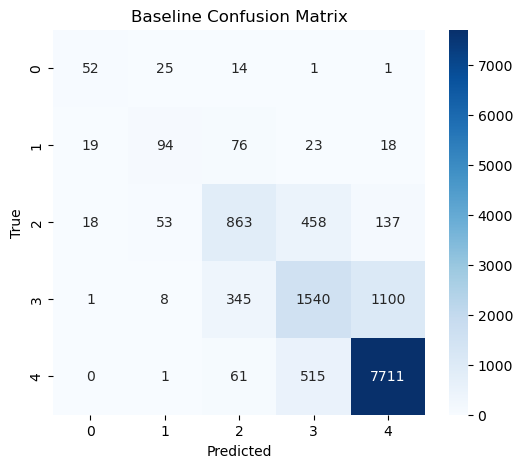

In [14]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
# 2. Load the saved model into it
xgb_model.load_model("my_xgb_model_day_4.json")

xgb_results1 = evaluate_xgb_baseline(X_te_aug[:,-1,:], y_flat_test , xgb_model,  label=f"XGB Baseline " )


In [15]:
n_tst = 100
X_inp = X_te_aug[n_tst:n_tst+1,-1,:]
#X_inp = np.ones([1, 166])*0.7
probs = xgb_model.predict_proba(X_inp)
preds = probs.argmax(axis=1)

preds


array([3])

In [24]:
X_inp = X_te_aug[n_tst:n_tst+1,-1,:]
X_inp

array([[0.    , 0.    , 0.    , 0.    , 0.    , 0.1799, 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.36  , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 

In [17]:
import joblib
model = xgb_model
joblib.dump(model, "egfr_stage_model.pkl")

['egfr_stage_model.pkl']

# Model load

In [18]:
import joblib

model = joblib.load("egfr_stage_model.pkl")

In [19]:
from pydantic import BaseModel

class InputData(BaseModel):
    features: list[float]

In [22]:
from fastapi import FastAPI
from pydantic import BaseModel

# 1. Define your input data structure (if you haven't already)
class InputData(BaseModel):
    features: list  # Adjust this to match your model's expected input

# 2. INITIALIZE THE APP (This is the missing piece!)
app = FastAPI()

# 3. Now your route will work
@app.post("/predict")
def predict(data: InputData):
    prediction = model.predict([data.features])
    #return {"prediction": prediction.tolist()}
    return {
        "stage": int(prediction[0])
    }

SyntaxError: invalid syntax (1223348983.py, line 1)